In [1]:
import os
import pickle
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

matplotlib.rcParams['text.usetex'] = False

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [2]:
project_root = "../../../.."

error_rate_level = "typical"  # "typical", "high", "stress"

LOAD_PROCESSED_DATA = False

In [3]:
if error_rate_level == "typical":
    indel_rate = "5e-06"
    sub_rate = "0.004"
elif error_rate_level == "high":
    indel_rate = "1.25e-05"
    sub_rate = "0.01"
elif error_rate_level == "stress":
    indel_rate = "3.75e-05"
    sub_rate = "0.03"
else:
    raise ValueError(f"Invalid error_rate_level: {error_rate_level}")

all_test_accessions = open(
    f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt"
).read().splitlines()

genome_info_df = pd.read_csv(
    f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv"
)
genome_info_df = genome_info_df.set_index('accession')

TT4_FAMILIES = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        translation_table = 4 if row['family'] in TT4_FAMILIES else 11
        all_genomes[acc] = {
            'family': row['family'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table,
        }

print(f"Total test accessions: {len(all_test_accessions)}")
print(f"Error rates: indel={indel_rate}, substitution={sub_rate}")

read_lengths = [75, 100, 150, 300]

model_names = [
    "deep_cds_a2_no_errors", "deep_cds_a2_substitution", "deep_cds_a2_errors",
    "deep_cds_a1_no_errors", "deep_cds_a1_substitution", "deep_cds_a1_errors",
    "deep_cds_no_errors",    "deep_cds_substitution",    "deep_cds_errors",
]

models_per_length = {length: model_names for length in read_lengths}

model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS
model_markers = MODEL_MARKERS

_script_name = "start_stop_codon_evaluation_across_ablation_models"
_cache_dir = (
    f"{project_root}/data/processed_data/report_results/with_errors/{_script_name}"
    f"/{indel_rate}i_{sub_rate}s"
)

Total test accessions: 215
Error rates: indel=5e-06, substitution=0.004


In [4]:
def get_full_cds(reads_dict):
    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']
        indices_to_remove = []
        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [cds_index - 1 for cds_index in cds_frag_mapping]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]
                start_cds_frag = cds_coords[min(cds_frag_mapping)][0]
                end_cds_frag = cds_coords[max(cds_frag_mapping)][1]
                indices_to_remove += cds_frag_mapping
                assert start_cds_frag < end_cds_frag
                cds_coords.append([start_cds_frag, end_cds_frag, 'disrupted_rf'])
                reads_dict[read]['cds_coords'] = cds_coords
        for index in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(index)
    return reads_dict


def calculate_iou(coord1, coord2):
    start1, stop1, rf1 = coord1
    start2, stop2, rf2 = coord2
    if rf1 != rf2:
        return 0.0
    intersection_start = max(start1, start2)
    intersection_stop = min(stop1, stop2)
    if intersection_start >= intersection_stop:
        return 0.0
    intersection_length = intersection_stop - intersection_start
    union_start = min(start1, start2)
    union_stop = max(stop1, stop2)
    union_length = union_stop - union_start
    return intersection_length / union_length if union_length > 0 else 0.0


def find_matching_genes(predicted_coords, actual_coords):
    matched_pairs = []
    used_actual = set()
    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        for actual_idx, actual_coord in enumerate(actual_coords):
            if actual_idx in used_actual:
                continue
            iou = calculate_iou(pred_coord, actual_coord)
            if iou == 1.0 and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
    return matched_pairs, len(matched_pairs)


def calculate_metrics(testset_dict, model_preds_dict, all_test_read_names):
    total_tp = 0
    total_predicted_genes = 0
    total_actual_genes = 0
    for read_name in all_test_read_names:
        cds_coords_testset = testset_dict.get(read_name, {}).get("cds_coords", [])
        cds_coords_model = model_preds_dict.get(read_name, {}).get("cds_coords", [])
        num_predicted = len(cds_coords_model)
        num_actual = len(cds_coords_testset)
        _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset)
        total_predicted_genes += num_predicted
        total_actual_genes += num_actual
        total_tp += tp_count
    total_fp = total_predicted_genes - total_tp
    total_fn = total_actual_genes - total_tp
    precision = total_tp / total_predicted_genes if total_predicted_genes > 0 else 0.0
    recall = total_tp / total_actual_genes if total_actual_genes > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    return {
        'total_predicted_genes': total_predicted_genes,
        'total_actual_genes': total_actual_genes,
        'total_true_positives': total_tp,
        'total_false_positives': total_fp,
        'total_false_negatives': total_fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1_score, 3)
    }

In [5]:
def load_testset(test_accession, data_type, project_root=project_root):
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)
    return read_names_list, get_full_cds(testset_dict)


def load_model_preds(test_accession, data_type, model_name, project_root=project_root):
    preds_base = f"{project_root}/data/processed_data/predictions/processed_predictions"
    pred_paths = {
        "deep_cds_a2_no_errors":    f"{preds_base}/DeepCDS_codon_only/model_without_errors/{data_type}/codon_only_model_all_genomes_d332_seed_42_final/{test_accession}/model_preds_dict.pkl",
        "deep_cds_a2_substitution": f"{preds_base}/DeepCDS_codon_only/model_with_substitution_errors/{data_type}/codon_only_model_all_genomes_d332_seed_42_final/{test_accession}/model_preds_dict.pkl",
        "deep_cds_a2_errors":       f"{preds_base}/DeepCDS_codon_only/model_with_errors/{data_type}/codon_only_model_all_genomes_d332_seed_42_final/{test_accession}/model_preds_dict.pkl",
        "deep_cds_a1_no_errors":    f"{preds_base}/DeepCDS_A1/model_without_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{test_accession}/model_preds_dict.pkl",
        "deep_cds_a1_substitution": f"{preds_base}/DeepCDS_A1/model_with_substitution_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{test_accession}/model_preds_dict.pkl",
        "deep_cds_a1_errors":       f"{preds_base}/DeepCDS_A1/model_with_errors/{data_type}/esm2_8m_all_genomes_seed_42_trained_final_no_dropout/{test_accession}/model_preds_dict.pkl",
        "deep_cds_no_errors":       f"{preds_base}/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
        "deep_cds_substitution":    f"{preds_base}/DeepCDS/model_with_substitution_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
        "deep_cds_errors":          f"{preds_base}/DeepCDS/model_with_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return get_full_cds(preds)

In [6]:
def is_internal_start(start, rf):
    if rf == 'disrupted_rf':
        return start in {1, 2, 3}
    rf_int = int(rf)
    return start == rf_int + 1


def is_internal_stop(stop, seq_len, rf):
    return stop >= seq_len - 2


def get_codon_sets(cds_coords, seq_len):
    real_starts = set()
    real_stops = set()
    for start, stop, rf in cds_coords:
        if not is_internal_start(start, rf):
            real_starts.add((start, rf))
        if not is_internal_stop(stop, seq_len, rf):
            real_stops.add((stop, rf))
    return real_starts, real_stops


def compute_codon_detection_counts(pred_coords, actual_coords, seq_len):
    pred_starts, pred_stops = get_codon_sets(pred_coords, seq_len)
    actual_starts, actual_stops = get_codon_sets(actual_coords, seq_len)
    start_tp = len(pred_starts & actual_starts)
    start_fp = len(pred_starts - actual_starts)
    start_fn = len(actual_starts - pred_starts)
    stop_tp = len(pred_stops & actual_stops)
    stop_fp = len(pred_stops - actual_stops)
    stop_fn = len(actual_stops - pred_stops)
    return start_tp, start_fp, start_fn, stop_tp, stop_fp, stop_fn

# Evaluate start/stop codon prediction across read lengths

In [7]:
if not LOAD_PROCESSED_DATA:
    def _init_codon_dict():
        return {
            length: {model: {
                'start_tp': 0, 'start_fp': 0, 'start_fn': 0,
                'stop_tp': 0,  'stop_fp': 0,  'stop_fn': 0,
            } for model in model_names}
            for length in read_lengths
        }

    def _init_has_data_dict():
        return {length: {model: False for model in model_names} for length in read_lengths}

    results = _init_codon_dict()
    has_data = _init_has_data_dict()

    per_genome_metrics_list = {
        length: {model: {
            'start_f1': [], 'start_precision': [], 'start_recall': [],
            'stop_f1': [],  'stop_precision': [],  'stop_recall': [],
        } for model in model_names}
        for length in read_lengths
    }

    for length in read_lengths:
        data_type = f"with_errors_{indel_rate}i_{sub_rate}s_{length}bp"
        seq_len = length
        available_models = models_per_length[length]
        print(f"\nProcessing {data_type} (models: {', '.join(available_models)})...")

        for test_accession in tqdm(all_test_accessions, desc=f"{length}bp"):
            tt = all_genomes.get(test_accession, {}).get('translation_table', None)
            if tt == 4:
                continue
            try:
                read_names_list, testset_dict = load_testset(test_accession, data_type)
            except Exception:
                continue

            for model in available_models:
                try:
                    preds = load_model_preds(test_accession, data_type, model)
                except Exception:
                    continue

                has_data[length][model] = True
                pg_s_tp = pg_s_fp = pg_s_fn = 0
                pg_e_tp = pg_e_fp = pg_e_fn = 0

                for read_name in read_names_list:
                    actual    = testset_dict.get(read_name, {}).get('cds_coords', [])
                    predicted = preds.get(read_name, {}).get('cds_coords', [])
                    s_tp, s_fp, s_fn, e_tp, e_fp, e_fn = compute_codon_detection_counts(
                        predicted, actual, seq_len)
                    results[length][model]['start_tp'] += s_tp
                    results[length][model]['start_fp'] += s_fp
                    results[length][model]['start_fn'] += s_fn
                    results[length][model]['stop_tp']  += e_tp
                    results[length][model]['stop_fp']  += e_fp
                    results[length][model]['stop_fn']  += e_fn
                    pg_s_tp += s_tp; pg_s_fp += s_fp; pg_s_fn += s_fn
                    pg_e_tp += e_tp; pg_e_fp += e_fp; pg_e_fn += e_fn

                s_prec = pg_s_tp / (pg_s_tp + pg_s_fp) if (pg_s_tp + pg_s_fp) > 0 else 0.0
                s_rec  = pg_s_tp / (pg_s_tp + pg_s_fn) if (pg_s_tp + pg_s_fn) > 0 else 0.0
                s_f1   = 2 * s_prec * s_rec / (s_prec + s_rec) if (s_prec + s_rec) > 0 else 0.0
                e_prec = pg_e_tp / (pg_e_tp + pg_e_fp) if (pg_e_tp + pg_e_fp) > 0 else 0.0
                e_rec  = pg_e_tp / (pg_e_tp + pg_e_fn) if (pg_e_tp + pg_e_fn) > 0 else 0.0
                e_f1   = 2 * e_prec * e_rec / (e_prec + e_rec) if (e_prec + e_rec) > 0 else 0.0
                per_genome_metrics_list[length][model]['start_f1'].append(s_f1)
                per_genome_metrics_list[length][model]['start_precision'].append(s_prec)
                per_genome_metrics_list[length][model]['start_recall'].append(s_rec)
                per_genome_metrics_list[length][model]['stop_f1'].append(e_f1)
                per_genome_metrics_list[length][model]['stop_precision'].append(e_prec)
                per_genome_metrics_list[length][model]['stop_recall'].append(e_rec)

else:
    print(f"Loading pre-computed results from:\n  {_cache_dir}")
    with open(os.path.join(_cache_dir, "results.pkl"), "rb") as f:
        results = pickle.load(f)
    with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
        has_data = pickle.load(f)
    with open(os.path.join(_cache_dir, "per_genome_metrics_list.pkl"), "rb") as f:
        per_genome_metrics_list = pickle.load(f)


Processing with_errors_5e-06i_0.004s_75bp (models: deep_cds_a2_no_errors, deep_cds_a2_substitution, deep_cds_a2_errors, deep_cds_a1_no_errors, deep_cds_a1_substitution, deep_cds_a1_errors, deep_cds_no_errors, deep_cds_substitution, deep_cds_errors)...


75bp: 100%|██████████| 215/215 [07:46<00:00,  2.17s/it]



Processing with_errors_5e-06i_0.004s_100bp (models: deep_cds_a2_no_errors, deep_cds_a2_substitution, deep_cds_a2_errors, deep_cds_a1_no_errors, deep_cds_a1_substitution, deep_cds_a1_errors, deep_cds_no_errors, deep_cds_substitution, deep_cds_errors)...


100bp: 100%|██████████| 215/215 [05:25<00:00,  1.51s/it]



Processing with_errors_5e-06i_0.004s_150bp (models: deep_cds_a2_no_errors, deep_cds_a2_substitution, deep_cds_a2_errors, deep_cds_a1_no_errors, deep_cds_a1_substitution, deep_cds_a1_errors, deep_cds_no_errors, deep_cds_substitution, deep_cds_errors)...


150bp: 100%|██████████| 215/215 [03:43<00:00,  1.04s/it]



Processing with_errors_5e-06i_0.004s_300bp (models: deep_cds_a2_no_errors, deep_cds_a2_substitution, deep_cds_a2_errors, deep_cds_a1_no_errors, deep_cds_a1_substitution, deep_cds_a1_errors, deep_cds_no_errors, deep_cds_substitution, deep_cds_errors)...


300bp: 100%|██████████| 215/215 [02:10<00:00,  1.65it/s]


In [8]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    for _name, _obj in {"results": results, "has_data": has_data, "per_genome_metrics_list": per_genome_metrics_list}.items():
        with open(os.path.join(_cache_dir, f"{_name}.pkl"), "wb") as f:
            pickle.dump(_obj, f)
    print(f"Results saved to {_cache_dir}")

Results saved to ../../../../data/processed_data/report_results/with_errors/start_stop_codon_evaluation_across_ablation_models/5e-06i_0.004s


In [9]:
def safe_div(a, b):
    return a / b if b > 0 else 0.0

metrics = {model: {
    'start_precision': [], 'start_recall': [], 'start_f1': [],
    'stop_precision': [], 'stop_recall': [], 'stop_f1': [],
} for model in model_names}

for length in read_lengths:
    for model in model_names:
        if not has_data[length][model]:
            for key in metrics[model]:
                metrics[model][key].append(np.nan)
            continue
        r = results[length][model]
        s_prec = safe_div(r['start_tp'], r['start_tp'] + r['start_fp'])
        s_rec = safe_div(r['start_tp'], r['start_tp'] + r['start_fn'])
        s_f1 = safe_div(2 * s_prec * s_rec, s_prec + s_rec)
        e_prec = safe_div(r['stop_tp'], r['stop_tp'] + r['stop_fp'])
        e_rec = safe_div(r['stop_tp'], r['stop_tp'] + r['stop_fn'])
        e_f1 = safe_div(2 * e_prec * e_rec, e_prec + e_rec)
        metrics[model]['start_precision'].append(s_prec)
        metrics[model]['start_recall'].append(s_rec)
        metrics[model]['start_f1'].append(s_f1)
        metrics[model]['stop_precision'].append(e_prec)
        metrics[model]['stop_recall'].append(e_rec)
        metrics[model]['stop_f1'].append(e_f1)

# Plots: Start and stop codon prediction by read length

In [17]:
def plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, metric_key, ylabel, title):
    active_models = [m for m in model_names
                     if any(per_genome_metrics_list[l][m][metric_key] for l in read_lengths)]
    if not active_models:
        print("No data available.")
        return

    n_active = len(active_models)
    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(11, 7))

    x_positions = np.arange(len(read_lengths))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    for k, model in enumerate(active_models):
        color = model_colors[model]
        positions, data = [], []
        for i, length in enumerate(read_lengths):
            vals = per_genome_metrics_list[length][model][metric_key]
            if vals:
                positions.append(x_positions[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.9,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5,
                            markerfacecolor=color, markeredgecolor=color),
            manage_ticks=False,
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7,
                label=model_display_names[model])

    ax.set_xlabel('Read Length (bp)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=14)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(l) for l in read_lengths])
    ax.set_ylim(0, 1.01)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=3)
    plt.tight_layout()
    plt.show()

## Start codon prediction

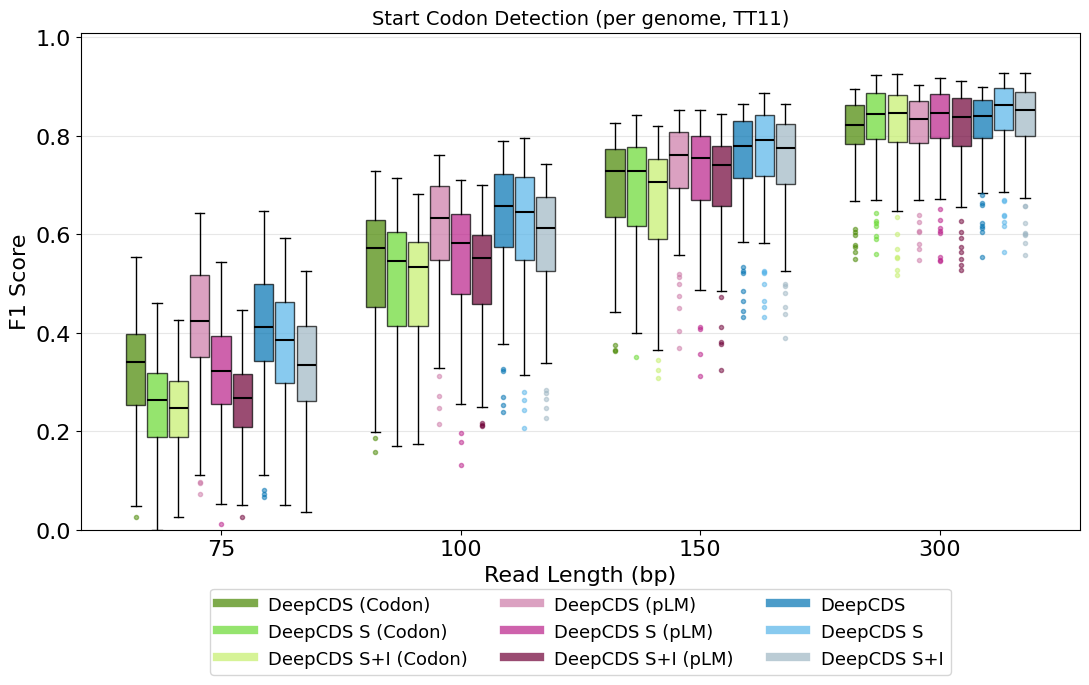

In [18]:
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'start_f1', 'F1 Score', 'Start Codon Detection (per genome, TT11)')

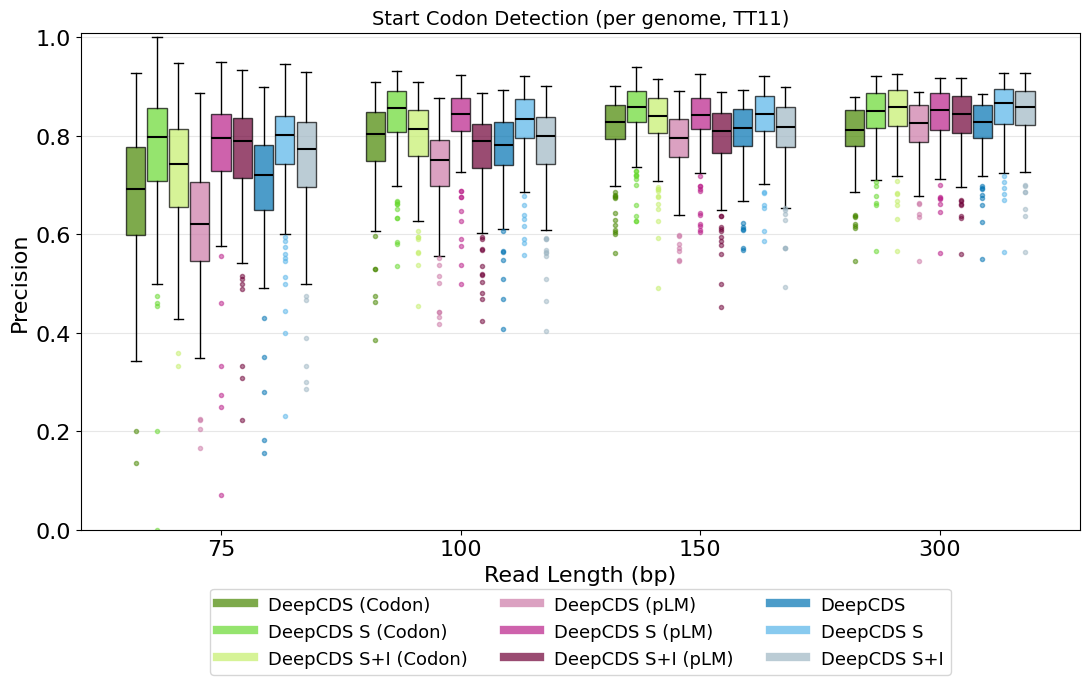

In [19]:
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'start_precision', 'Precision', 'Start Codon Detection (per genome, TT11)')

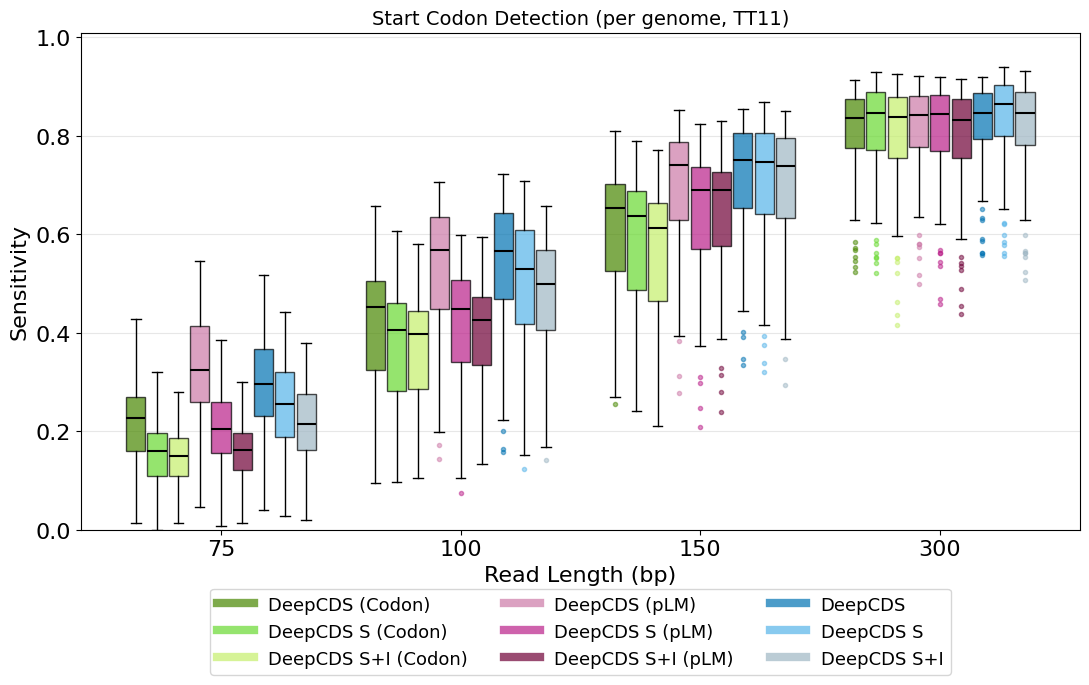

In [20]:
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'start_recall', 'Sensitivity', 'Start Codon Detection (per genome, TT11)')

## Stop codon prediction

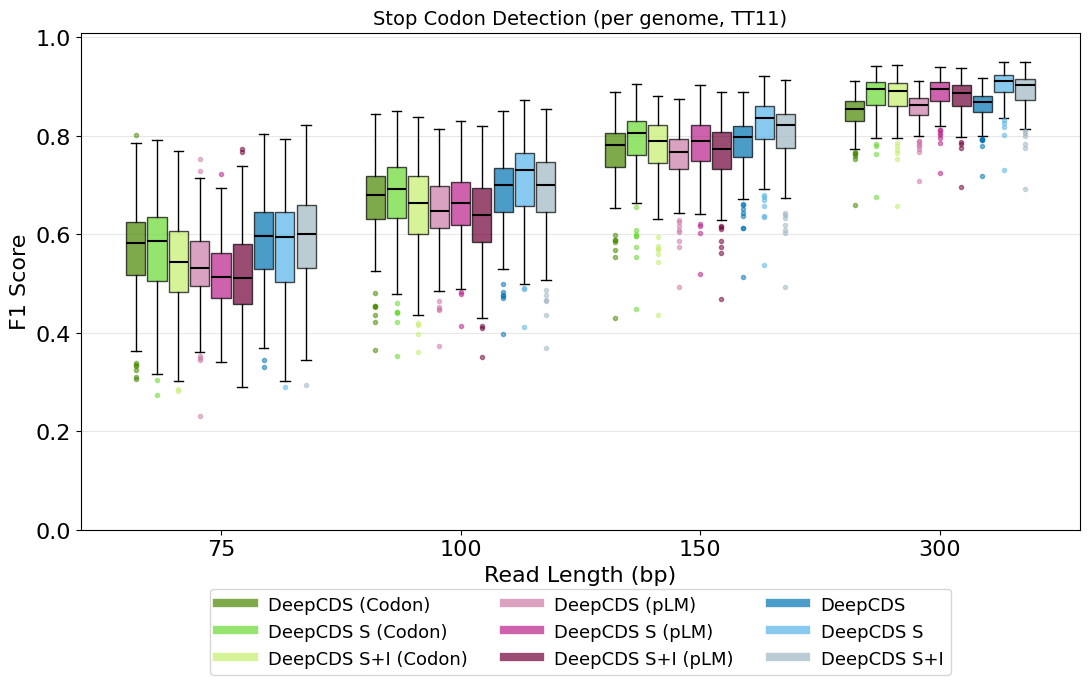

In [21]:
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'stop_f1', 'F1 Score', 'Stop Codon Detection (per genome, TT11)')

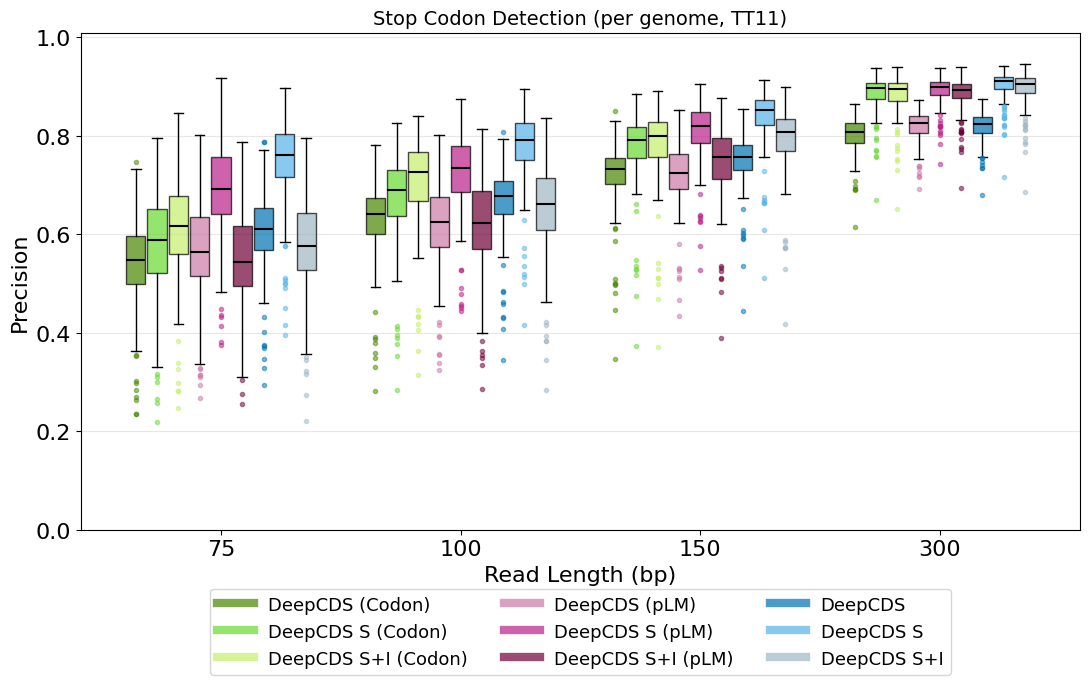

In [22]:
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'stop_precision', 'Precision', 'Stop Codon Detection (per genome, TT11)')

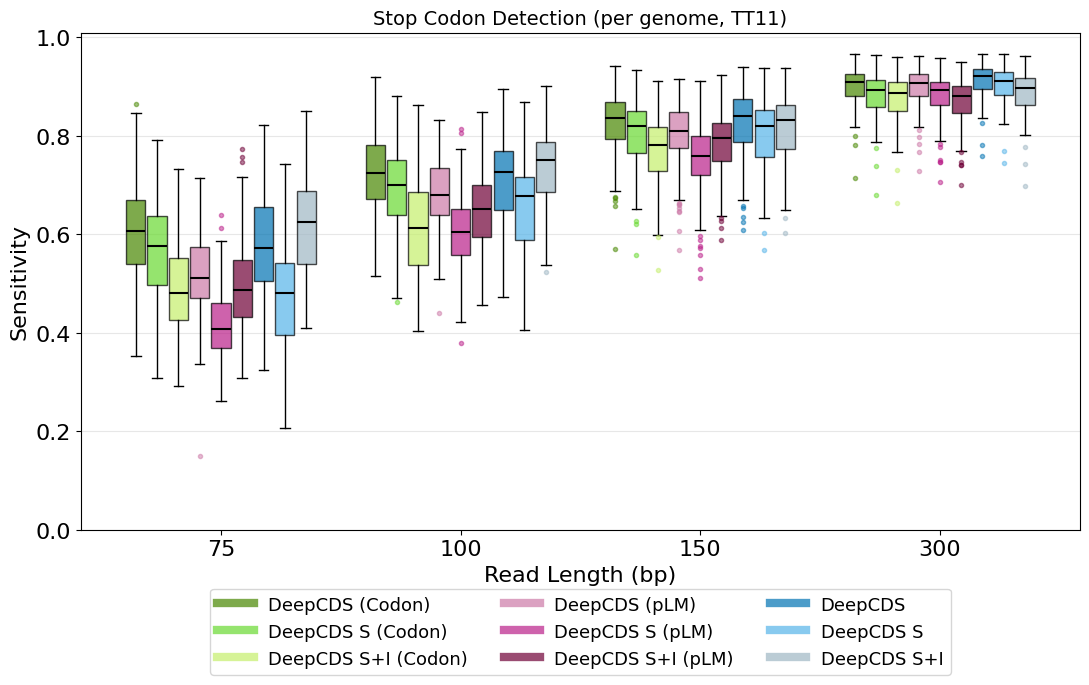

In [23]:
plot_codon_metric_boxplot(per_genome_metrics_list, read_lengths, 'stop_recall', 'Sensitivity', 'Stop Codon Detection (per genome, TT11)')